In [5]:
# !pip install ale_py stable_baselines3
# !pip install --upgrade moviepy

In [6]:
import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3.common.env_util import make_atari_env

In [7]:
import gymnasium as gym

env_id = "ALE/Riverraid-v5"
env = make_atari_env(env_id,n_envs=1,seed=0)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [110, 156,  66],
        [110, 156,  66],
        [110, 156,  66]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]], dtype=uint8)
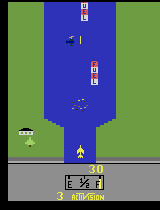

In [8]:
obs = env.reset()
env.render()

In [12]:
episodes=32
frames = []
reward_history_before = []
episodes_total_reward = 0

for episode  in range(episodes):
    obs = env.reset()
    done = False
    total_reward = 0
    while not done:
        action = env.action_space.sample()
        action = [action]
        obs,reward,done,info = env.step(action)
        total_reward += reward[0]
        frames.append(env.render())
    episodes_total_reward += total_reward
    reward_history_before.append(total_reward)
    print(f"Before Training - Episode {episode+1} - Total Reward: {total_reward}")

print(f"Average Reward Before Training: {np.mean(reward_history_before)}")


Before Training - Episode 1 - Total Reward: 0.0
Before Training - Episode 2 - Total Reward: 2.0
Before Training - Episode 3 - Total Reward: 1.0
Before Training - Episode 4 - Total Reward: 4.0
Before Training - Episode 5 - Total Reward: 2.0
Before Training - Episode 6 - Total Reward: 1.0
Before Training - Episode 7 - Total Reward: 6.0
Before Training - Episode 8 - Total Reward: 2.0
Before Training - Episode 9 - Total Reward: 2.0
Before Training - Episode 10 - Total Reward: 1.0
Before Training - Episode 11 - Total Reward: 1.0
Before Training - Episode 12 - Total Reward: 1.0
Before Training - Episode 13 - Total Reward: 2.0
Before Training - Episode 14 - Total Reward: 1.0
Before Training - Episode 15 - Total Reward: 2.0
Before Training - Episode 16 - Total Reward: 2.0
Before Training - Episode 17 - Total Reward: 8.0
Before Training - Episode 18 - Total Reward: 1.0
Before Training - Episode 19 - Total Reward: 1.0
Before Training - Episode 20 - Total Reward: 2.0
Before Training - Episode 21 

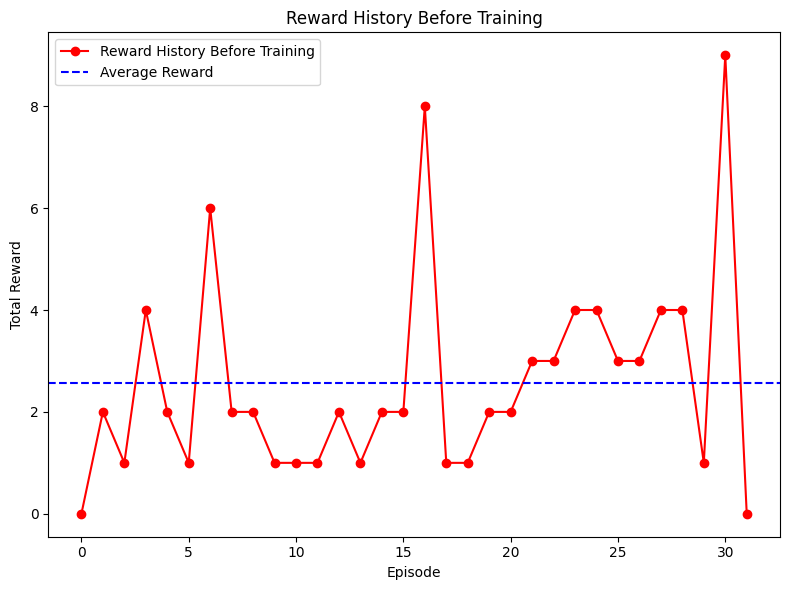

In [14]:
plt.figure(figsize=(8,6))
plt.plot(reward_history_before,label="Reward History Before Training",color="red",linestyle='-',marker='o')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Reward History Before Training")
plt.axhline(y=np.mean(reward_history_before),color="blue",linestyle="--",label="Average Reward")
plt.tight_layout()
plt.legend()
plt.show()

In [15]:
from moviepy import ImageSequenceClip
import os


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
main_dir = "/content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari"
id=env_id.split("/")[-1]
clip_id = f"randeom-{id}.mp4"
clip_path  = os.path.join(main_dir,clip_id)

In [18]:
print("Creating Video , please wait ...")

clip = ImageSequenceClip(frames,fps=10)
clip.write_videofile(clip_path)
print("Video Created Successfully")
env.close()

Creating Video , please wait ...
MoviePy - Building video /content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari/randeom-Riverraid-v5.mp4.
MoviePy - Writing video /content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari/randeom-Riverraid-v5.mp4



MoviePy - Done !
MoviePy - video ready /content/drive/MyDrive/husob/06 ReinForcement Learning/008 Atari/randeom-Riverraid-v5.mp4
Video Created Successfully
